# Validation-Stage Model Comparison

This notebook compares traditional statistical models and machine learning/deep learning models on the historical training-validation framework.

The model routing rule used here is based on validation-set predictive performance. Specifically, if a machine learning model improves MAPE relative to the best traditional model for a product family, the machine learning model is selected as the validation-stage winner for that family.

However, this routing result should not be interpreted as an unconditional production-deployment decision. A model can perform well on validation MAPE but still require additional checks before being used for out-of-sample forecasting and downstream inventory optimization.

Therefore, the output of this notebook should be interpreted as:

> The best model by validation accuracy, not necessarily the final model used for deployment.

The final out-of-sample forecasting decision is made later after checking model artifact reliability, inference stability, forecast continuity, and operational feasibility.

## Notebook Role in the Forecasting Pipeline

| Item | Description |
|---|---|
| Notebook role | Validation-stage model comparison |
| Main question | Which model performs best by validation MAPE for each family? |
| Main output | Validation winner by product family |
| Not final by itself | Final deployment still requires artifact reliability and feasibility checks |

In [1]:
import os
import numpy as np # mathematic calculations
import pandas as pd # exploratory data analysis
import scipy.stats as stats # statistics
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
import datetime as dt # date data manipulation
import time # training and predicting time recording
import ast
import joblib

# Import Time Series Analysis libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import ARIMA, SARIMAX

# Libraries for Machine Learning Models
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_log_error
import category_encoders as ce

# Neural Network
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from keras.models import Model
import keras_tuner as kt
from scikeras.wrappers import KerasRegressor
from scipy.stats import loguniform, randint, uniform

C:\Users\Asus\anaconda3\envs\inventory-analytics\lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
MAIN = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System'
RESULT = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/results/'
MODELS = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/models/'
DATA = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/data/'

In [3]:
trad_fitted_model = pd.read_csv(RESULT + 'production_traditional_fitted_values.csv')
trad_fitted_model

,date,family,Actual_Sales,Fitted_Sales
0,2013-04-07,BEVERAGES,441419.00000,651443.647171
1,2013-04-14,BEVERAGES,412046.00000,497972.522436
2,2013-04-21,BEVERAGES,399330.00000,495848.229470
3,2013-04-28,BEVERAGES,394891.00000,435634.090151
4,2013-05-05,BEVERAGES,452789.00000,421817.231233
...,...,...,...,...
2285,2017-07-23,PRODUCE,873335.97112,906995.971183
2286,2017-07-30,PRODUCE,858957.30588,968841.082681
2287,2017-08-06,PRODUCE,915560.97195,897749.219066
2288,2017-08-13,PRODUCE,821552.83723,923147.573196


In [4]:
ml_fitted_model = pd.read_csv(RESULT + 'production_fitted_values.csv')
ml_fitted_model

,date,family,Actual_Sales,Fitted_Sales
0,2013-01-06,BEVERAGES,343176.00000,NaN
1,2013-01-13,BEVERAGES,395261.00000,NaN
2,2013-01-20,BEVERAGES,398667.00000,NaN
3,2013-01-27,BEVERAGES,363118.00000,NaN
4,2013-02-03,BEVERAGES,379430.00000,NaN
...,...,...,...,...
2415,2017-07-23,PRODUCE,873335.97112,872561.60
2416,2017-07-30,PRODUCE,858957.30588,852566.56
2417,2017-08-06,PRODUCE,915560.97195,882472.50
2418,2017-08-13,PRODUCE,821552.83723,916858.25


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_metrics(df):
    metrics = []
    # Loop over each family
    for family, group in df.groupby('family'):
        # Drop rows where sales/fitted values might be NaN to prevent metric calculation errors
        group = group.dropna(subset=['Actual_Sales', 'Fitted_Sales'])
        if len(group) == 0:
            continue
            
        actual = group['Actual_Sales']
        fitted = group['Fitted_Sales']
        
        # Calculate MAE and RMSE
        mae = mean_absolute_error(actual, fitted)
        rmse = np.sqrt(mean_squared_error(actual, fitted))
        
        # Calculate MAPE, avoiding division by zero
        mask = actual != 0
        if mask.sum() == 0:
            mape = np.nan
        else:
            mape = np.mean(np.abs((actual[mask] - fitted[mask]) / actual[mask])) * 100
            
        metrics.append({
            'family': family,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape
        })
    return pd.DataFrame(metrics)

# Calculate metrics for both dataframes
trad_metrics = compute_metrics(trad_fitted_model)
ml_metrics = compute_metrics(ml_fitted_model)

# Merge the metrics side-by-side
merged_metrics = pd.merge(trad_metrics, ml_metrics, on='family', suffixes=('_Trad', '_ML'))

# Calculate how much better the ML model performed compared to the Traditional model (in percentage)
# Formula: ((Trad_Metric - ML_Metric) / Trad_Metric) * 100
# This metric compares validation-stage predictive accuracy.
# It identifies whether the ML/DL model improves MAPE relative to the traditional baseline.
# It is not the only criterion for final out-of-sample deployment because deployment also requires
# reliable saved model artifacts, stable inference behavior, and operationally plausible forecasts.
### Validation-stage routing rule:
# If ML/DL improves validation MAPE, it is marked as the validation winner.
# This does not automatically mean that the same model will be used in the final test forecast.
# Final deployment routing is decided later after artifact reliability and feasibility checks.
merged_metrics['MAE_Better_%'] = ((merged_metrics['MAE_Trad'] - merged_metrics['MAE_ML']) / merged_metrics['MAE_Trad']) * 100
merged_metrics['RMSE_Better_%'] = ((merged_metrics['RMSE_Trad'] - merged_metrics['RMSE_ML']) / merged_metrics['RMSE_Trad']) * 100
merged_metrics['MAPE_Better_%'] = ((merged_metrics['MAPE_Trad'] - merged_metrics['MAPE_ML']) / merged_metrics['MAPE_Trad']) * 100

# Display the final dataframe
display(merged_metrics)


,family,MAE_Trad,RMSE_Trad,MAPE_Trad,MAE_ML,RMSE_ML,MAPE_ML,MAE_Better_%,RMSE_Better_%,MAPE_Better_%
0,BEVERAGES,99826.200951,152188.473683,11.136889,102779.670699,148810.734744,11.323365,-2.958612,2.219445,-1.674393
1,BREAD/BAKERY,9803.047783,13424.057839,5.422537,13159.853806,18947.115193,7.555429,-34.242473,-41.142979,-39.333836
2,CLEANING,31293.924828,42438.932722,7.443776,40925.671179,53954.330320,9.781718,-30.778326,-27.134041,-31.408006
3,DAIRY,54624.627119,69132.836339,19.387999,23046.864873,31677.277635,8.242728,57.808655,54.179115,57.485411
4,DELI,6458.244420,8930.790122,6.311629,9187.216088,12669.799570,9.416856,-42.255627,-41.866502,-49.198493
5,GROCERY I,118905.060846,186807.239185,7.641640,134900.318769,209015.880163,8.533263,-13.452125,-11.888533,-11.667949
6,MEATS,9798.164562,15795.551037,8.206676,9816.670101,15003.312848,7.874592,-0.188867,5.015578,4.046509
7,PERSONAL CARE,10339.137551,15169.996501,9.946639,12780.869192,18284.263614,12.213070,-23.616396,-20.529122,-22.785895
8,POULTRY,10030.746002,13977.399256,7.620018,11854.653532,16379.728123,8.983394,-18.183169,-17.187238,-17.892040
9,PRODUCE,72824.029526,111994.058712,852.225288,66711.152817,139590.038522,21.504849,8.394038,-24.640575,97.476624


In [6]:
# Save the final merged dataframe to the results directory
merged_metrics.to_csv(RESULT + 'ml_trad_model_comparison.csv', index=False)

In [7]:
# Create an empty list to store the final chosen dataframes for each family
final_selected_data = []

for family in merged_metrics['family']:
    # Get the MAPE_Better_% for this family
    mape_better = merged_metrics.loc[merged_metrics['family'] == family, 'MAPE_Better_%'].values[0]
    
    if mape_better >= 0:
        # If ML is better by 0% or more, take the ML model's actual and fitted values
        family_data = ml_fitted_model[ml_fitted_model['family'] == family].copy()
        family_data['model_used'] = 'ML'
    else:
        # Otherwise, take the Traditional model's actual and fitted values
        family_data = trad_fitted_model[trad_fitted_model['family'] == family].copy()
        family_data['model_used'] = 'Traditional'
        
    final_selected_data.append(family_data)

# Concatenate all the selected family dataframes into one final dataframe
hybrid_fitted_model = pd.concat(final_selected_data, ignore_index=True)

# Save to the results directory (optional)
# hybrid_fitted_model.to_csv(RESULT + 'hybrid_fitted_values.csv', index=False)

display(hybrid_fitted_model)

,date,family,Actual_Sales,Fitted_Sales,model_used
0,2013-04-07,BEVERAGES,441419.00000,651443.647171,Traditional
1,2013-04-14,BEVERAGES,412046.00000,497972.522436,Traditional
2,2013-04-21,BEVERAGES,399330.00000,495848.229470,Traditional
3,2013-04-28,BEVERAGES,394891.00000,435634.090151,Traditional
4,2013-05-05,BEVERAGES,452789.00000,421817.231233,Traditional
...,...,...,...,...,...
2324,2017-07-23,PRODUCE,873335.97112,872561.600000,ML
2325,2017-07-30,PRODUCE,858957.30588,852566.560000,ML
2326,2017-08-06,PRODUCE,915560.97195,882472.500000,ML
2327,2017-08-13,PRODUCE,821552.83723,916858.250000,ML


In [8]:
hybrid_fitted_model.groupby('family')['model_used'].value_counts()

family         model_used 
BEVERAGES      Traditional    229
BREAD/BAKERY   Traditional    229
CLEANING       Traditional    229
DAIRY          ML             242
DELI           Traditional    229
GROCERY I      Traditional    229
MEATS          ML             242
PERSONAL CARE  Traditional    229
POULTRY        Traditional    229
PRODUCE        ML             242
Name: count, dtype: int64

In [9]:
# Save the final hybrid dataframe to the results directory
hybrid_fitted_model.to_csv(RESULT + 'hybrid_fitted_values.csv', index=False)

In [10]:
hybrid_fitted_model = pd.read_csv(RESULT + 'hybrid_fitted_values.csv')
hybrid_fitted_model

,date,family,Actual_Sales,Fitted_Sales,model_used
0,2013-04-07,BEVERAGES,441419.00000,651443.647171,Traditional
1,2013-04-14,BEVERAGES,412046.00000,497972.522436,Traditional
2,2013-04-21,BEVERAGES,399330.00000,495848.229470,Traditional
3,2013-04-28,BEVERAGES,394891.00000,435634.090151,Traditional
4,2013-05-05,BEVERAGES,452789.00000,421817.231233,Traditional
...,...,...,...,...,...
2324,2017-07-23,PRODUCE,873335.97112,872561.600000,ML
2325,2017-07-30,PRODUCE,858957.30588,852566.560000,ML
2326,2017-08-06,PRODUCE,915560.97195,882472.500000,ML
2327,2017-08-13,PRODUCE,821552.83723,916858.250000,ML


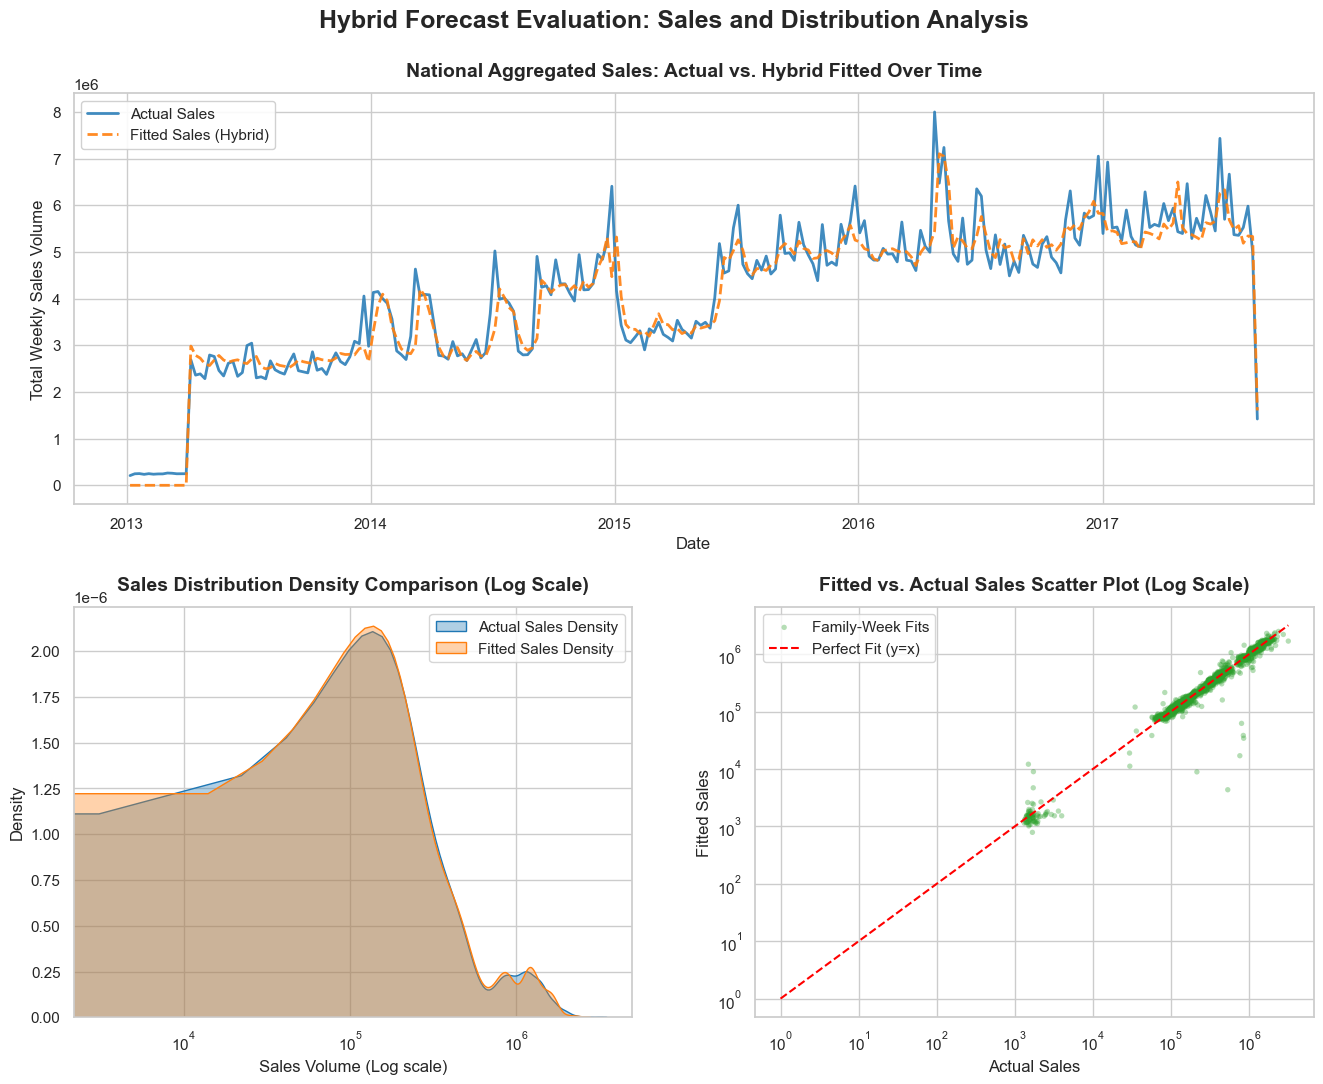

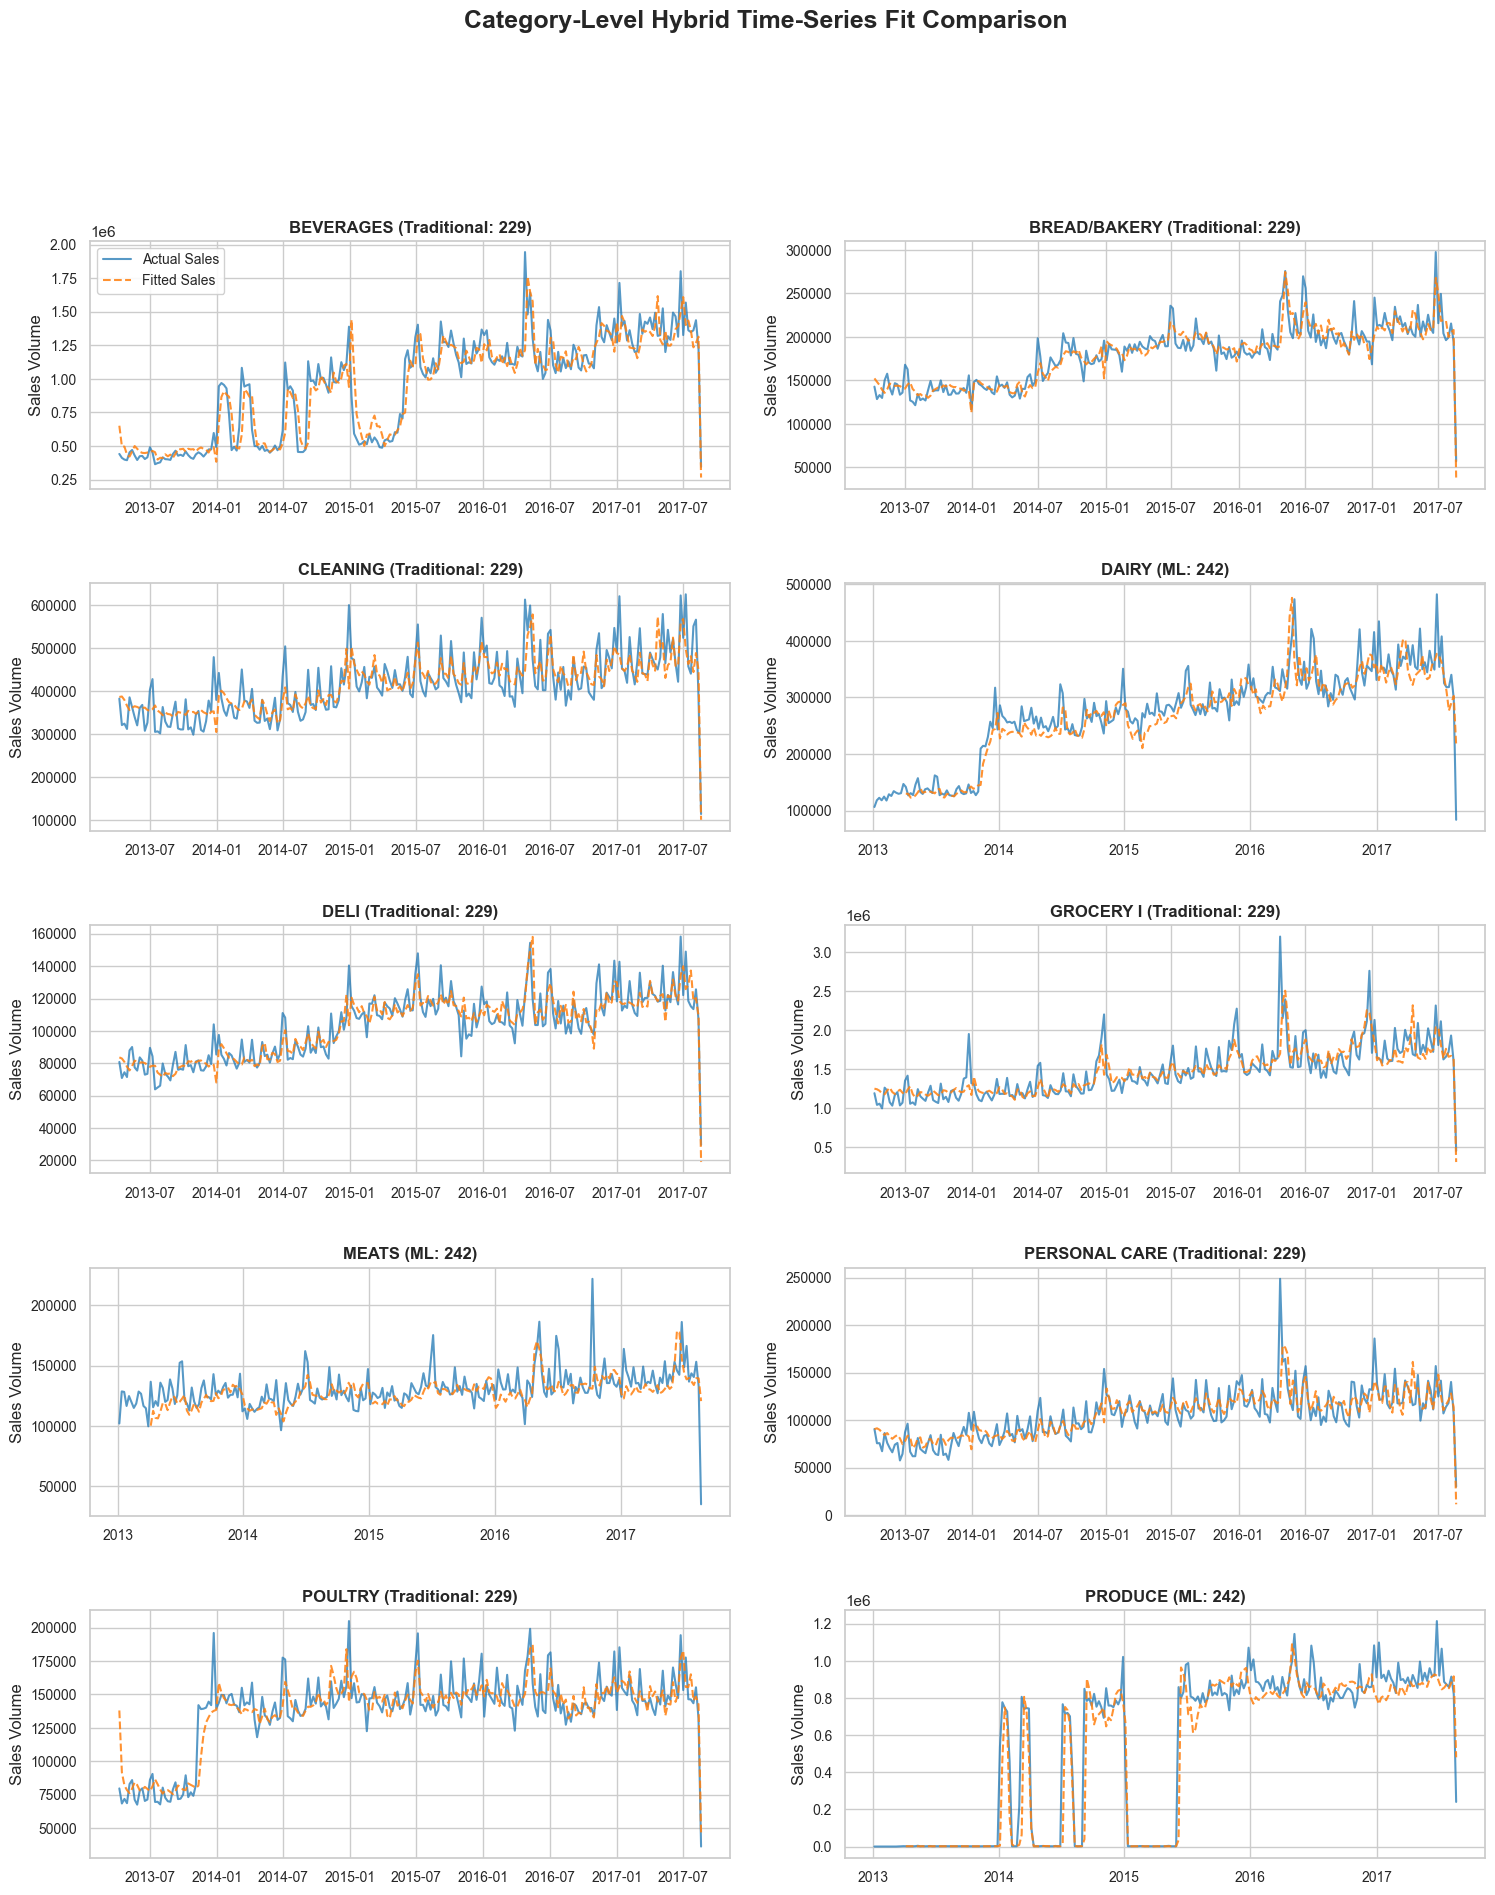

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================================
# 1. ENVIRONMENT & DATA SAFING
# ===================================================================
if 'hybrid_fitted_values' not in locals() and 'hybrid_fitted_values' not in globals():
    try:
        csv_path = os.path.join(RESULT, 'hybrid_fitted_values.csv')
    except NameError:
        csv_path = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/hybrid_fitted_values.csv'
    hybrid_fitted_values = pd.read_csv(csv_path)

# Ensure 'date' is parsed as datetime for proper time-series rendering
hybrid_fitted_values['date'] = pd.to_datetime(hybrid_fitted_values['date'])

# Set up clean premium plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})

# ===================================================================
# 2. OVERALL AGGREGATED SALES & DISTRIBUTION ANALYSIS (FIGURE 1)
# ===================================================================
# Aggregate actuals and fitted sales across all families per week
national_sales = hybrid_fitted_values.groupby('date')[['Actual_Sales', 'Fitted_Sales']].sum().reset_index()

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Adjust spacing safely
fig.subplots_adjust(hspace=0.25, wspace=0.22)

# Panel 1: Aggregated Timeline (Spans full width)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(national_sales['date'], national_sales['Actual_Sales'], label='Actual Sales', color='#1f77b4', linewidth=2, alpha=0.85)
ax1.plot(national_sales['date'], national_sales['Fitted_Sales'], label='Fitted Sales (Hybrid)', color='#ff7f0e', linewidth=2, linestyle='--', alpha=0.9)
ax1.set_title('National Aggregated Sales: Actual vs. Hybrid Fitted Over Time', fontweight='bold', pad=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Weekly Sales Volume')
ax1.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# Panel 2: Density / KDE Comparison (Log scale)
ax2 = fig.add_subplot(gs[1, 0])
sns.kdeplot(data=hybrid_fitted_values, x='Actual_Sales', fill=True, color='#1f77b4', label='Actual Sales Density', ax=ax2, alpha=0.35)
sns.kdeplot(data=hybrid_fitted_values, x='Fitted_Sales', fill=True, color='#ff7f0e', label='Fitted Sales Density', ax=ax2, alpha=0.35)
ax2.set_xscale('log')
ax2.set_title('Sales Distribution Density Comparison (Log Scale)', fontweight='bold', pad=12)
ax2.set_xlabel('Sales Volume (Log scale)')
ax2.set_ylabel('Density')
ax2.legend(frameon=True, facecolor='white')

# Panel 3: Scatter Plot of Fitted vs. Actual Sales (Log Scale)
ax3 = fig.add_subplot(gs[1, 1])
# Draw a random sample of records for cleaner visualization (prevents overplotting)
sample_df = hybrid_fitted_values.sample(min(len(hybrid_fitted_values), 5000), random_state=42)
ax3.scatter(sample_df['Actual_Sales'], sample_df['Fitted_Sales'], color='#2ca02c', alpha=0.35, edgecolors='none', s=15, label='Family-Week Fits')

# Draw diagonal y=x helper line
max_val = max(hybrid_fitted_values['Actual_Sales'].max(), hybrid_fitted_values['Fitted_Sales'].max())
ax3.plot([1, max_val], [1, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect Fit (y=x)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_title('Fitted vs. Actual Sales Scatter Plot (Log Scale)', fontweight='bold', pad=12)
ax3.set_xlabel('Actual Sales')
ax3.set_ylabel('Fitted Sales')
ax3.legend(frameon=True, facecolor='white')

# Save visual to results/dashboard_plots if directories exist
try:
    plot_save_path = os.path.join(RESULT, 'dashboard_plots', 'hybrid_overall_fitted_evaluation.png')
    plt.savefig(plot_save_path, bbox_inches='tight', dpi=150)
except Exception:
    pass

plt.suptitle('Hybrid Forecast Evaluation: Sales and Distribution Analysis', fontweight='bold', y=0.95)
plt.show()

# ===================================================================
# 3. CATEGORY-LEVEL FIT COMPARISON (FIGURE 2)
# ===================================================================
families = hybrid_fitted_values['family'].unique()
n_families = len(families)

# Set up grid subplots based on family count
n_rows = int(np.ceil(n_families / 2))
fig_fam, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.2 * n_rows))

# Adjust spacing safely
fig_fam.subplots_adjust(hspace=0.38, wspace=0.18)
axes = axes.flatten()

for idx, family in enumerate(families):
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].sort_values('date')
    ax = axes[idx]
    
    ax.plot(fam_data['date'], fam_data['Actual_Sales'], label='Actual Sales', color='#1f77b4', linewidth=1.5, alpha=0.75)
    ax.plot(fam_data['date'], fam_data['Fitted_Sales'], label='Fitted Sales', color='#ff7f0e', linewidth=1.5, linestyle='--', alpha=0.85)
    
    # Identify which model route was chosen for this category (ML vs Traditional)
    model_counts = fam_data['model_used'].value_counts()
    model_str = ", ".join([f"{k}: {v}" for k, v in model_counts.items()])
    
    ax.set_title(f"{family} ({model_str})", fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Sales Volume')
    ax.tick_params(axis='both', which='major', labelsize=10)
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

# Delete empty grids if any remain
for idx in range(n_families, len(axes)):
    fig_fam.delaxes(axes[idx])

try:
    plot_save_path2 = os.path.join(RESULT, 'dashboard_plots', 'hybrid_family_fitted_evaluation.png')
    plt.savefig(plot_save_path2, bbox_inches='tight', dpi=150)
except Exception:
    pass

plt.suptitle('Category-Level Hybrid Time-Series Fit Comparison', fontweight='bold', y=0.99, fontsize=18)
plt.show()

                       RAW SALES NORMALITY METRICS BY PRODUCT FAMILY                       


,Family,Actual Skewness,Actual Excess Kurtosis,Actual Normality p-val,Actual Is Normal?,Fitted Skewness,Fitted Excess Kurtosis,Fitted Normality p-val,Fitted Is Normal?
0,BEVERAGES,-0.11,-1.20,2.43e-25,NO,-0.14,-1.26,2.90e-37,NO
1,BREAD/BAKERY,0.05,0.60,2.04e-01,YES,-0.32,0.88,1.07e-02,NO
2,CLEANING,0.33,1.08,4.15e-03,NO,-0.36,3.20,9.85e-07,NO
3,DAIRY,-0.48,0.21,1.04e-02,NO,-0.49,-0.09,1.19e-02,NO
4,DELI,-0.05,0.03,8.96e-01,YES,-0.42,0.68,5.99e-03,NO
5,GROCERY I,1.15,3.29,1.15e-13,NO,0.56,2.08,2.37e-06,NO
6,MEATS,0.48,10.37,3.44e-14,NO,1.28,4.40,2.10e-16,NO
7,PERSONAL CARE,0.83,3.48,8.75e-11,NO,-0.01,1.41,9.06e-03,NO
8,POULTRY,-1.11,1.30,4.46e-10,NO,-1.44,1.42,1.34e-13,NO
9,PRODUCE,-0.46,-1.61,0.00e+00,NO,-0.40,-1.74,0.00e+00,NO


[SUCCESS] Saved Distribution Plot to: C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/results/dashboard_plots\hybrid_family_densities_normality.png


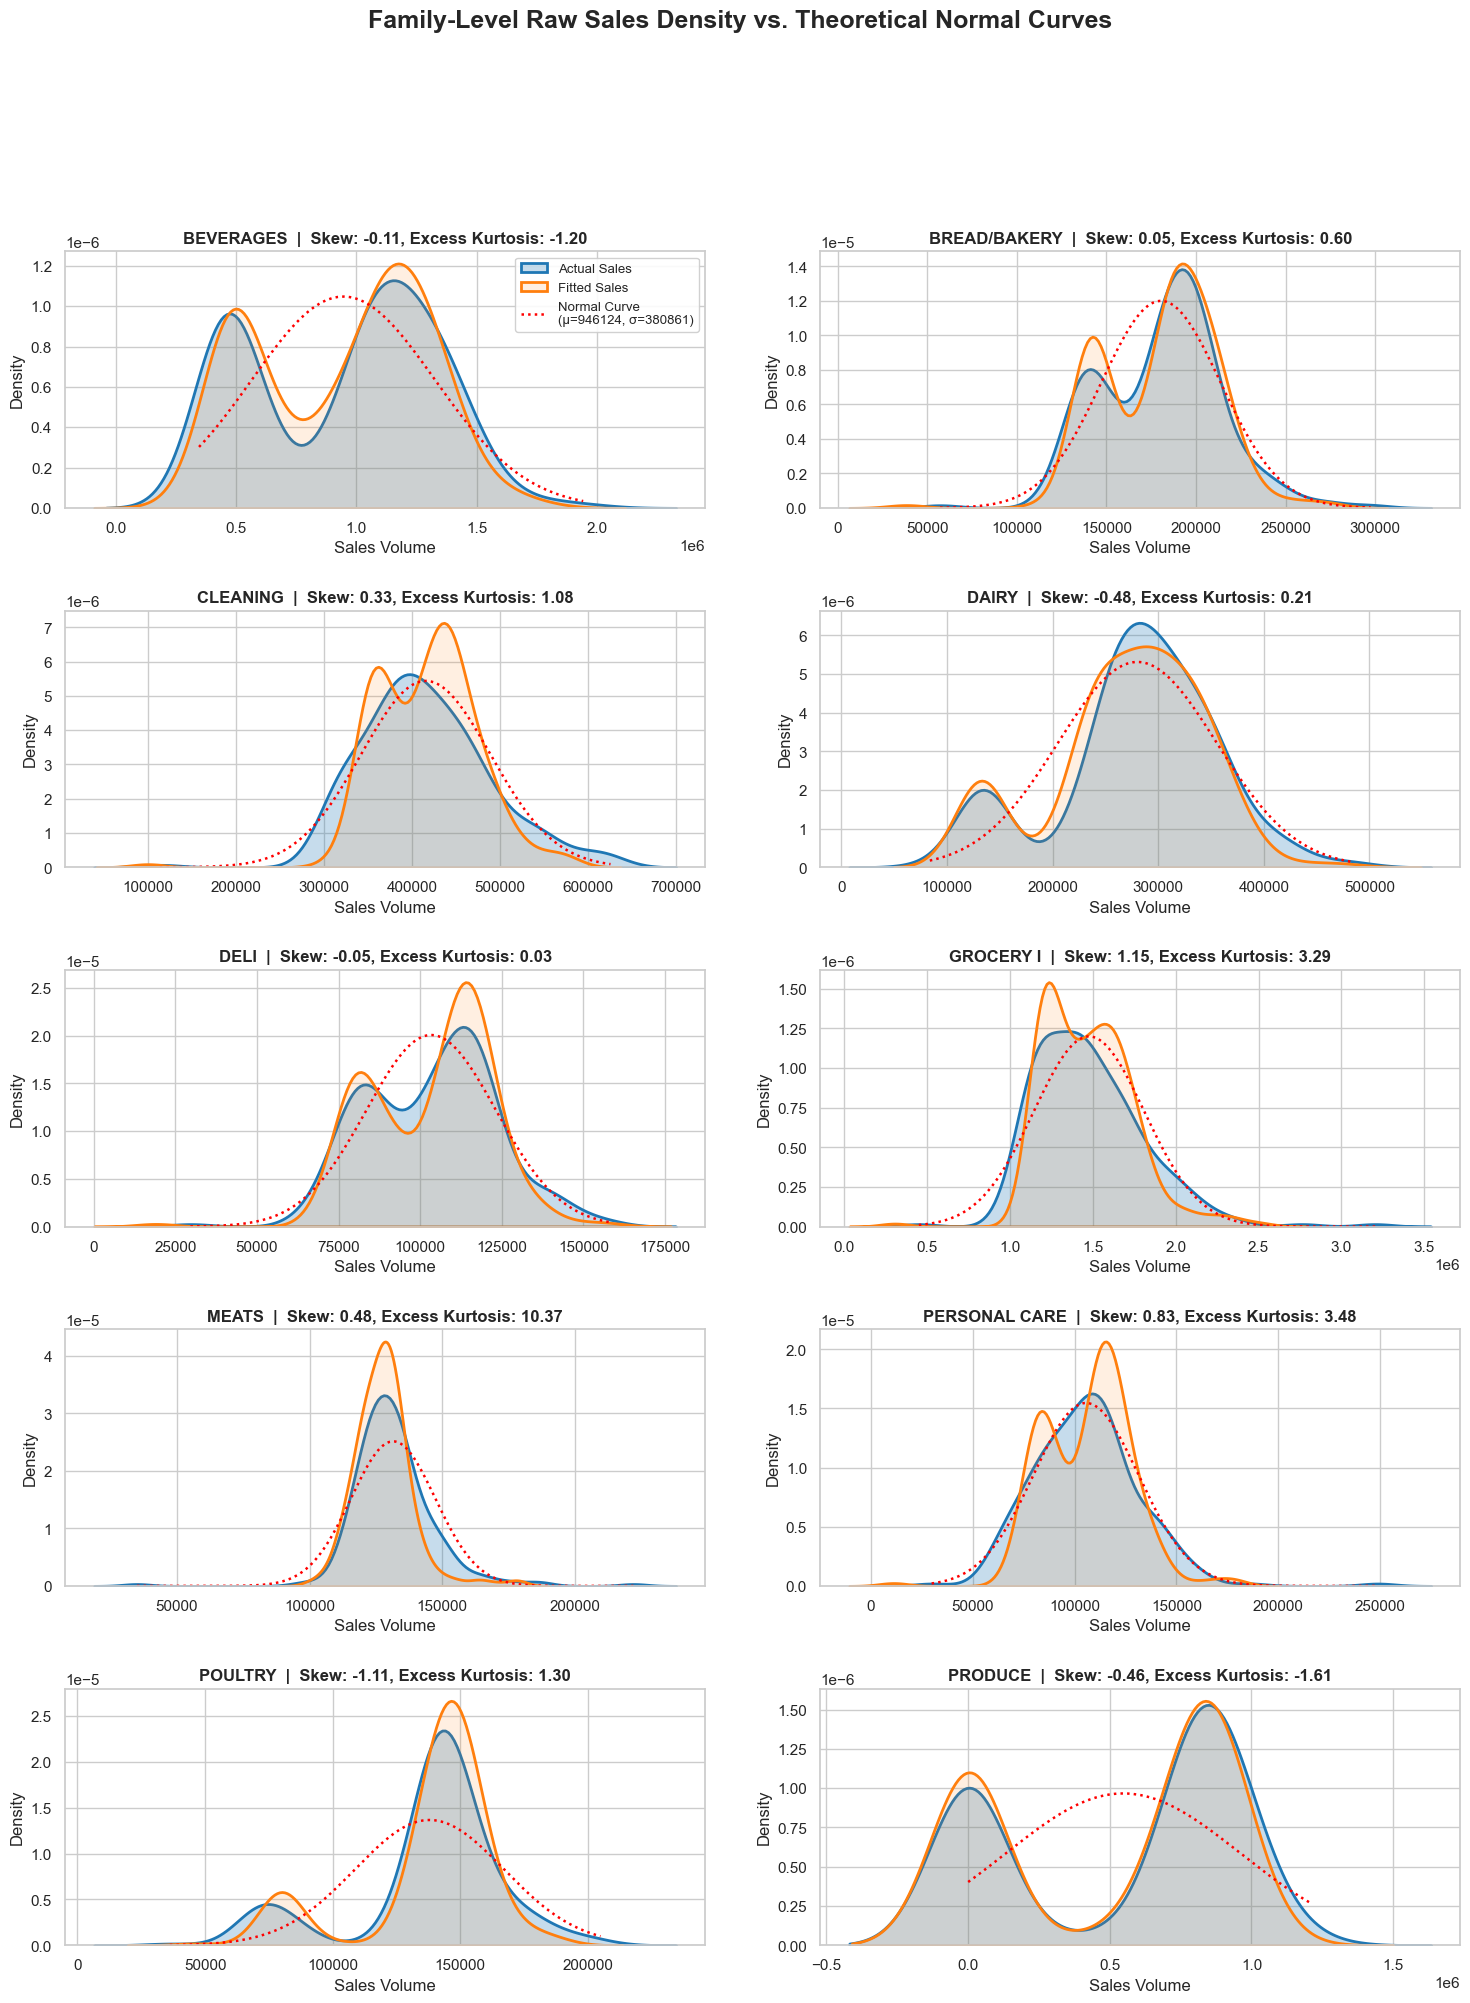

[SUCCESS] Saved Q-Q Plot to: C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/results/dashboard_plots\hybrid_family_qq_normality.png


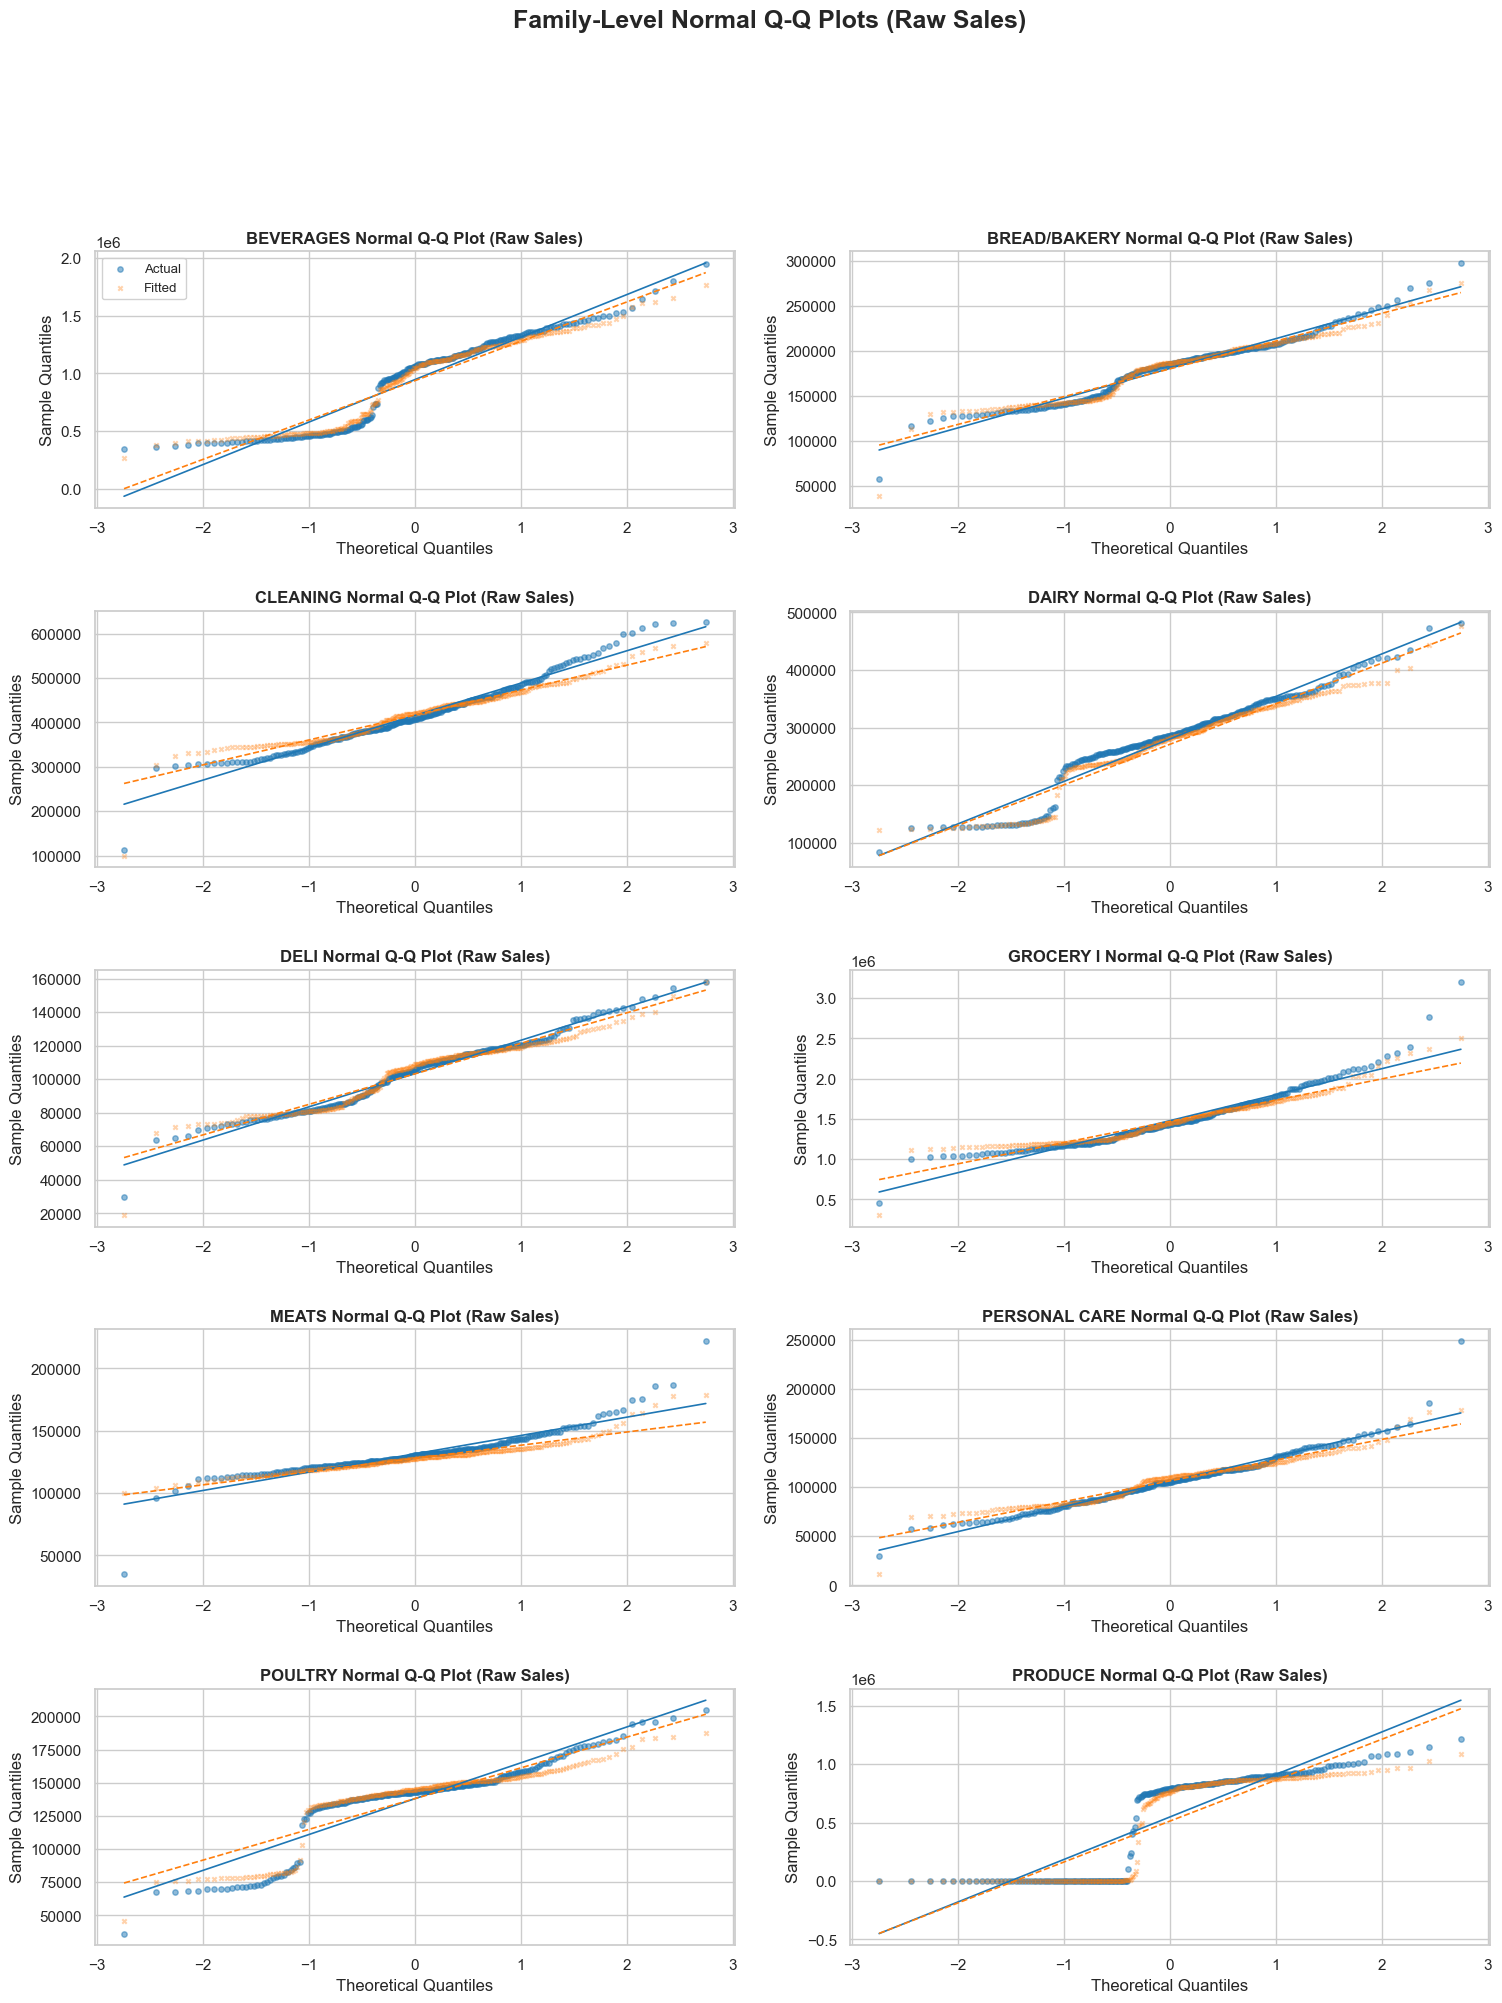

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ===================================================================
# 1. ENVIRONMENT & DATA LOAD CHECK
# ===================================================================
if 'hybrid_fitted_values' not in locals() and 'hybrid_fitted_values' not in globals():
    try:
        csv_path = os.path.join(RESULT, 'hybrid_fitted_values.csv')
    except NameError:
        csv_path = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/hybrid_fitted_values.csv'
    hybrid_fitted_values = pd.read_csv(csv_path)

# Ensure 'date' is parsed as datetime
hybrid_fitted_values['date'] = pd.to_datetime(hybrid_fitted_values['date'])

# Extract unique families
families = hybrid_fitted_values['family'].unique()
n_families = len(families)

# Create save directory fallback path in case RESULT is not defined
try:
    save_dir = os.path.join(RESULT, 'dashboard_plots')
except NameError:
    save_dir = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/dashboard_plots'
os.makedirs(save_dir, exist_ok=True)

# ===================================================================
# 2. TABULAR STATISTICAL NORMALITY METRICS BY FAMILY
# ===================================================================
normality_summary = []
for family in families:
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].dropna()
    act = fam_data['Actual_Sales'].values
    fit = fam_data['Fitted_Sales'].values
    
    # Compute metrics for Actuals (D'Agostino requires at least 8 samples)
    _, p_act = stats.normaltest(act) if len(act) >= 8 else (0, 0)
    skew_act = stats.skew(act)
    kurt_act = stats.kurtosis(act)
    
    # Compute metrics for Fitted
    _, p_fit = stats.normaltest(fit) if len(fit) >= 8 else (0, 0)
    skew_fit = stats.skew(fit)
    kurt_fit = stats.kurtosis(fit)
    
    normality_summary.append({
        'Family': family,
        'Actual Skewness': round(skew_act, 2),
        'Actual Excess Kurtosis': round(kurt_act, 2),
        'Actual Normality p-val': f"{p_act:.2e}",
        'Actual Is Normal?': 'YES' if p_act >= 0.05 else 'NO',
        'Fitted Skewness': round(skew_fit, 2),
        'Fitted Excess Kurtosis': round(kurt_fit, 2),
        'Fitted Normality p-val': f"{p_fit:.2e}",
        'Fitted Is Normal?': 'YES' if p_fit >= 0.05 else 'NO'
    })

summary_df = pd.DataFrame(normality_summary)
print("=" * 105)
print("                       RAW SALES NORMALITY METRICS BY PRODUCT FAMILY                       ")
print("=" * 105)
display(summary_df)
print("=" * 105)

# Setup layout configurations for 10 subplots (5 rows x 2 cols)
n_rows = int(np.ceil(n_families / 2))
sns.set_theme(style="whitegrid")

# ===================================================================
# 3. VISUAL 1: SALES DENSITY PLOTS BY FAMILY & SAVE (5x2 GRID)
# ===================================================================
fig_dist, axes_dist = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.4 * n_rows))
fig_dist.subplots_adjust(hspace=0.4, wspace=0.18)
axes_dist = axes_dist.flatten()

for idx, family in enumerate(families):
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].dropna()
    act = fam_data['Actual_Sales'].values
    fit = fam_data['Fitted_Sales'].values
    ax = axes_dist[idx]
    
    # Plot Actual and Fitted KDEs
    sns.kdeplot(act, ax=ax, color='#1f77b4', linewidth=2, fill=True, alpha=0.25, label='Actual Sales')
    sns.kdeplot(fit, ax=ax, color='#ff7f0e', linewidth=2, fill=True, alpha=0.12, label='Fitted Sales')
    
    # Overlay Theoretical Normal distribution matching that family's actual parameters
    mean_fam, std_fam = np.mean(act), np.std(act)
    x_vals = np.linspace(min(act), max(act), 1000)
    normal_curve = stats.norm.pdf(x_vals, mean_fam, std_fam)
    ax.plot(x_vals, normal_curve, color='red', linestyle=':', linewidth=1.8, 
            label=f'Normal Curve\n(μ={mean_fam:.0f}, σ={std_fam:.0f})')
    
    # Family headers displaying skewness and kurtosis
    ax.set_title(f"{family}  |  Skew: {stats.skew(act):.2f}, Excess Kurtosis: {stats.kurtosis(act):.2f}", fontweight='bold', fontsize=12)
    ax.set_xlabel('Sales Volume')
    ax.set_ylabel('Density')
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)

# Hide any unused axis plots
for idx in range(n_families, len(axes_dist)):
    fig_dist.delaxes(axes_dist[idx])

plt.suptitle('Family-Level Raw Sales Density vs. Theoretical Normal Curves', fontweight='bold', y=0.99, fontsize=18)

# Save distribution plot
try:
    plot_save_path1 = os.path.join(save_dir, 'hybrid_family_densities_normality.png')
    fig_dist.savefig(plot_save_path1, bbox_inches='tight', dpi=150)
    print(f"[SUCCESS] Saved Distribution Plot to: {plot_save_path1}")
except Exception as e:
    print(f"[WARNING] Could not save distribution plot: {e}")

plt.show()

# ===================================================================
# 4. VISUAL 2: NORMAL Q-Q PLOTS BY FAMILY & SAVE (5x2 GRID)
# ===================================================================
fig_qq, axes_qq = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.4 * n_rows))
fig_qq.subplots_adjust(hspace=0.4, wspace=0.18)
axes_qq = axes_qq.flatten()

for idx, family in enumerate(families):
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].dropna()
    act = fam_data['Actual_Sales'].values
    fit = fam_data['Fitted_Sales'].values
    ax = axes_qq[idx]
    
    # Theoretical normal Q-Q plot for Actuals
    (osm_act, osr_act), (slope_act, intercept_act, r_act) = stats.probplot(act, dist="norm")
    ax.scatter(osm_act, osr_act, color='#1f77b4', alpha=0.5, s=15, label='Actual')
    ax.plot(osm_act, slope_act*osm_act + intercept_act, color='#1f77b4', linestyle='-', linewidth=1.2)
    
    # Theoretical normal Q-Q plot for Fitted
    (osm_fit, osr_fit), (slope_fit, intercept_fit, r_fit) = stats.probplot(fit, dist="norm")
    ax.scatter(osm_fit, osr_fit, color='#ff7f0e', alpha=0.35, s=10, marker='x', label='Fitted')
    ax.plot(osm_fit, slope_fit*osm_fit + intercept_fit, color='#ff7f0e', linestyle='--', linewidth=1.2)
    
    ax.set_title(f"{family} Normal Q-Q Plot (Raw Sales)", fontweight='bold', fontsize=12)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)

# Hide any unused axis plots
for idx in range(n_families, len(axes_qq)):
    fig_qq.delaxes(axes_qq[idx])

plt.suptitle('Family-Level Normal Q-Q Plots (Raw Sales)', fontweight='bold', y=0.99, fontsize=18)

# Save Q-Q plot
try:
    plot_save_path2 = os.path.join(save_dir, 'hybrid_family_qq_normality.png')
    fig_qq.savefig(plot_save_path2, bbox_inches='tight', dpi=150)
    print(f"[SUCCESS] Saved Q-Q Plot to: {plot_save_path2}")
except Exception as e:
    print(f"[WARNING] Could not save Q-Q plot: {e}")

plt.show()